# Weather data from *AgroDataCube*

Find the KNMI meteorological station closest to a study area and retrieve its observations for a day, a period or a long period: `get_closest_meteostation()`, `get_meteo_for_date()`, `get_meteo_for_period()` and `get_meteo_for_long_period()`. The underlying REST requests are shown in [`advanced/agrodatacube_rest`](advanced/agrodatacube_rest.ipynb).

**Requires:** `ADC_TOKEN` environment variable

**Approximate runtime:** about 30 seconds

**Author:** Bruno Marcos

**Created in:** October 2, 2026

## Settings

In [1]:
# Load packages
pkgs <- c("sf", "rNDC")
suppressPackageStartupMessages(
  invisible(lapply(pkgs, FUN = library, character.only = TRUE))
)

# The AgroDataCube token is passed explicitly to the functions
adc_token <- Sys.getenv("ADC_TOKEN")

# Study area: one of the study sites bundled with the package
site <- ndc_sites("loobos")

## 1. Closest meteorological station

`get_closest_meteostation()` takes the study area as an `sf` object (in any CRS), or anything else that `ndc_roi()` accepts, or a WKT string (EPSG:4326). Its centroid is compared with the stations.

In [2]:
station <- get_closest_meteostation(site, token = adc_token)
station$closest_id
round(min(station$distances) / 1000, 1) # distance in km

[1] "275"
[1] 15


## 2. One day

In [3]:
day <- get_meteo_for_date(station$closest_id, "2025-07-15", token = adc_token)
st_drop_geometry(day)[, c("datum", "mean_temperature", "min_temperature", "max_temperature", "precipitation")]

       datum mean_temperature min_temperature max_temperature precipitation
1 2025-07-15             18.5            14.6            23.3           9.1


## 3. A period

One request is made (up to `page_size` rows).

In [4]:
week <- get_meteo_for_period(station$closest_id, "2025-07-01", "2025-07-07", token = adc_token)
st_drop_geometry(week)[, c("datum", "mean_temperature", "precipitation")]

       datum mean_temperature precipitation
1 2025-07-01             28.4           0.0
2 2025-07-02             24.7           2.1
3 2025-07-03             17.4           0.0
4 2025-07-04             18.1           0.0
5 2025-07-05             18.6           0.3
6 2025-07-06             17.2          12.8
7 2025-07-07             15.7           2.3


## 4. A long period

`get_meteo_for_long_period()` splits the period in chunks of `by_days` days and combines the results.

[1] 92


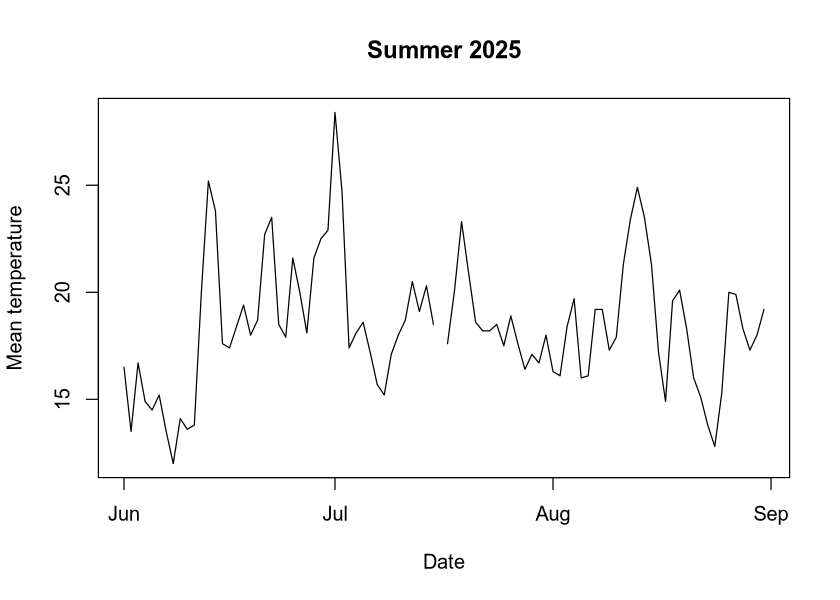

In [5]:
summer <- suppressMessages(
  get_meteo_for_long_period(station$closest_id, "2025-06-01", "2025-08-31", token = adc_token, by_days = 30)
)
nrow(summer)
plot(as.Date(summer$datum), summer$mean_temperature, type = "l",
     xlab = "Date", ylab = "Mean temperature", main = "Summer 2025")